# Workflow for HTT magspec analysis

This notebook shows the process to turn raw camera images all the way into energy waterfall plots 

In [13]:
# Boiler plate config/logging setup

import logging
import time
from IPython.display import Image, display


from geecs_data_utils import ScanPaths, ScanTag
from scan_analysis.analyzers.common.array2D_scan_analysis import Array2DScanAnalyzer

# import the desired ImageAnalyzer
from image_analysis.offline_analyzers.magspec_manual_calib_analyzer import (
    MagSpecManualCalibAnalyzer,
)

# BeamAnalyzer uses a configuration file for instantiation and use. So,
# we need to set the config path. But, any type of ImageAnalzyer can be used.
from geecs_data_utils.config_roots import image_analysis_config

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)

# Set the logging level. Can set to INFO or DEBUG to get more detail about the
# actual execution
logging.getLogger("image_analysis").setLevel(logging.ERROR)
logging.getLogger("scan_analysis").setLevel(logging.ERROR)
logging.getLogger("geecs_data_utils").setLevel(logging.WARNING)
logging.getLogger("logmaker_4_googledocs").setLevel(logging.ERROR)

image_analysis_config.set_base_dir(ScanPaths.paths_config.image_analysis_configs_path)

WindowsPath('//131.243.169.248/hdna2/software/control-all-loasis/HTU/Active Version/GEECS-Plugins-Configs/image_analysis_configs')

Create the 4 individual image analyzers for each camera

In [14]:
config_name1 = "HTT-MagCam1"
dev_name1 = "HTT-C23_1_MagSpec1"
image_analyzer1 = MagSpecManualCalibAnalyzer(camera_config_name=config_name1)

config_name2 = "HTT-MagCam2"
dev_name2 = "HTT-C23_2_MagSpec2"
image_analyzer2 = MagSpecManualCalibAnalyzer(camera_config_name=config_name2)

config_name3 = "HTT-MagCam3"
dev_name3 = "HTT-C23_3_MagSpec3"
image_analyzer3 = MagSpecManualCalibAnalyzer(camera_config_name=config_name3)

config_name4 = "HTT-MagCam4"
dev_name4 = "HTT-C23_4_MagSpec4"
image_analyzer4 = MagSpecManualCalibAnalyzer(camera_config_name=config_name4)

Create and run the scan analyzers for each camera for the specified scan tag. This applies the charge and energy calibrations for each individual image and saves the shot by shot data in dedicated new folders.

In [19]:
t0 = time.monotonic()

# ScanAnalyzers use ScanTag as an arg, which is a unique identifier, to
# determine which scan to process
year = 2026
month = 4
day = 10
number = 14
experiment = "Thomson"
test_tag = ScanTag(
    year=year, month=month, day=day, number=number, experiment=experiment
)

scan_analyzer1 = Array2DScanAnalyzer(
    image_analyzer=image_analyzer1, device_name=dev_name1, flag_save_images=True
)
scan_analyzer1.run_analysis(scan_tag=test_tag)

scan_analyzer2 = Array2DScanAnalyzer(
    image_analyzer=image_analyzer2, device_name=dev_name2, flag_save_images=True
)
scan_analyzer2.run_analysis(scan_tag=test_tag)

scan_analyzer3 = Array2DScanAnalyzer(
    image_analyzer=image_analyzer3, device_name=dev_name3, flag_save_images=True
)
scan_analyzer3.run_analysis(scan_tag=test_tag)

scan_analyzer4 = Array2DScanAnalyzer(
    image_analyzer=image_analyzer4, device_name=dev_name4, flag_save_images=True
)
scan_analyzer4.run_analysis(scan_tag=test_tag)

t1 = time.monotonic()
print(f"execution time: {t1 - t0}")

execution time: 18.375


After the indivddual the charge/energy calibrations are complete, we can use the line stitcher to stitch the individual charge per MeV vs Energy data. We define a normal 1D line config for the `master_device`, which in this case is "HTT-C23_1_MagSpec1-interpSpec". The paths to the `sibling_devices` are resolved using the master device by simply swapping the names. Once loaded, the stitched files are sorted and linearly interpolated and returned to the ImageAnalzyer for furhter pipeline processing and analysis. 

In [ ]:
from image_analysis.offline_analyzers.line_stitcher import LineStitcher
from scan_analysis.analyzers.common.array1d_scan_analysis import Array1DScanAnalyzer

config_name = "HTT-InterpSpec"
master_device = "HTT-C23_1_MagSpec1-interpSpec"

sibling_devices = [
    "HTT-C23_2_MagSpec2-interpSpec",
    "HTT-C23_3_MagSpec3-interpSpec",
    "HTT-C23_4_MagSpec4-interpSpec",
]
magspec_stitcher = LineStitcher(
    line_config_name=config_name,
    sibling_devices=sibling_devices,
    output_folder="HTT-C23_MagSpecAnalysis",
    output_label="HTT-C23_MagSpecStitched",
)

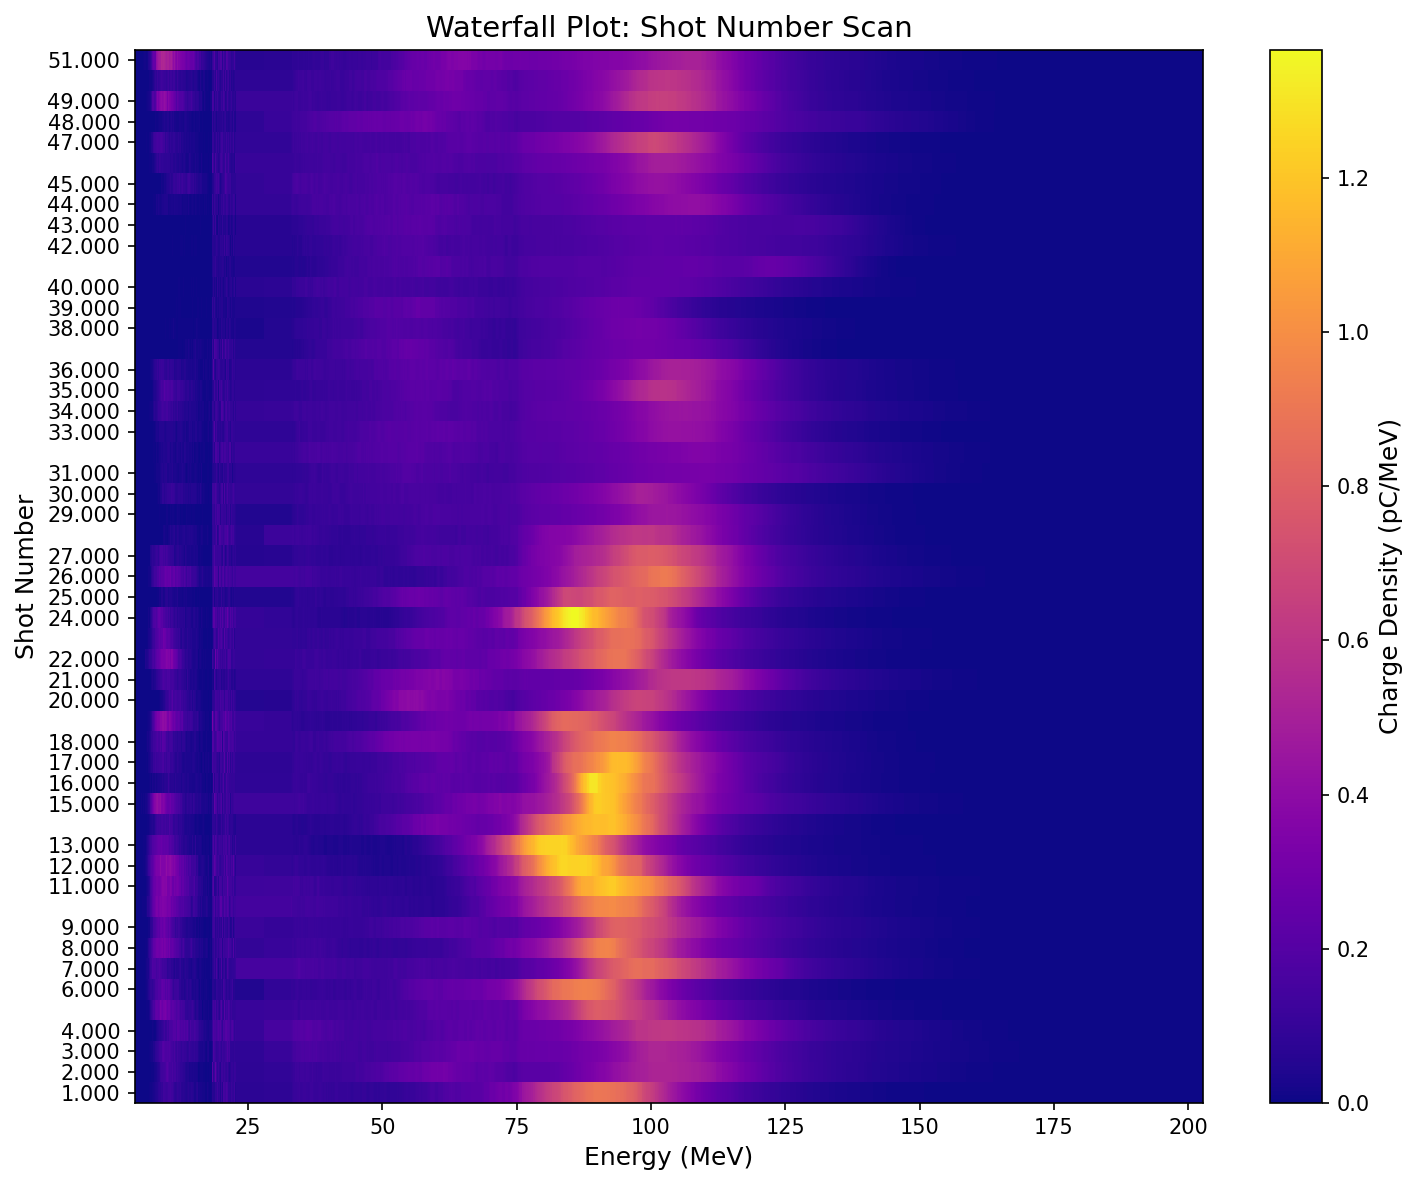

In [34]:
year = 2026
month = 4
day = 10
number = 11
experiment = "Thomson"

test_tag = ScanTag(
    year=year, month=month, day=day, number=number, experiment=experiment
)

dev_name = "HTT-C23_1_MagSpec1-interpSpec"


scan_analyzer_mag = Array1DScanAnalyzer(
    image_analyzer=magspec_stitcher, device_name=master_device, file_tail=".tsv"
)

# run the analysis
result = scan_analyzer_mag.run_analysis(scan_tag=test_tag)
t1 = time.monotonic()
# print(f"execution time: {t1 - t0}")
display(Image(filename=str(result[0]), width=500))